# Task 1 - Binary Classification Model : Data analysis and Pre processing investigation


### Motivation

The Flame dataset, used for training and testing in this project consist of sequential video frames and as such special care needs to be taken that the produced models secumb to over fitting, redundancy or data leakage. This Notebook covers the processing and analysis steps I take to avoid these cases, specifically in the Binary Fire vs No Fire classifier. I will also discuss if in this case all Data engineering steps are needed.

### Main focuses of this Notebook

This notebooks identifies the defining features of the Binary Classifier data. Considering each class, its components and how this would affect the running of the models later on. It will also demonstrate my development process, walking through my intial trails and comparisons and my final data processing. It will also specifically demonstrate what processing is needed to make the most effective model possible and what the least steps possible are needed to make an effective Binary Classifier.

### Steps followed

* Similarity between frames is evaluated and fitting data picking / hashing is trailed
* over fitting is tested and is taken into account when splitting data
* Class imbalance is evaluated and various ways of handling it are tested and whether these points are needed for this specific task are talked about

### Summary 

The goal is to create the cleanest and most reliable data set possible. It is also compare how far the data cleansing needs to be taken before becoming redundant.

In [ ]:
# importing necessary libraries

import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import os
from PIL import Image
import imagehash
import imageio.v3 as imageio
import pandas as pd
from collections import Counter
import random
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

# image size, batch size and random seed for reproducibility
Image_size = 96
Batch = 32
Random_seed = 42

### Data Exploration

Its important to understand the FLAME dataset. Being shot as multiple videos the dataset consists of multiple frames of images. Intitially 2 main problems became apparent.

* Size : The images are natively 225 x 225. This is way to large for a laptop ran ML model to handle. After comparing run time and model accuracy 96 x 96 was picked as the optimal image resizing. Any less would to heavily affect model performance and any more would produce a clunky and slow model.

* Frame Repititon : Being a video the images are incredibly similar. This makes any model liable to fitting onto the wrong features, the background and environment more so than the signs of an actual fire. This is demonstrated by the plotting below.

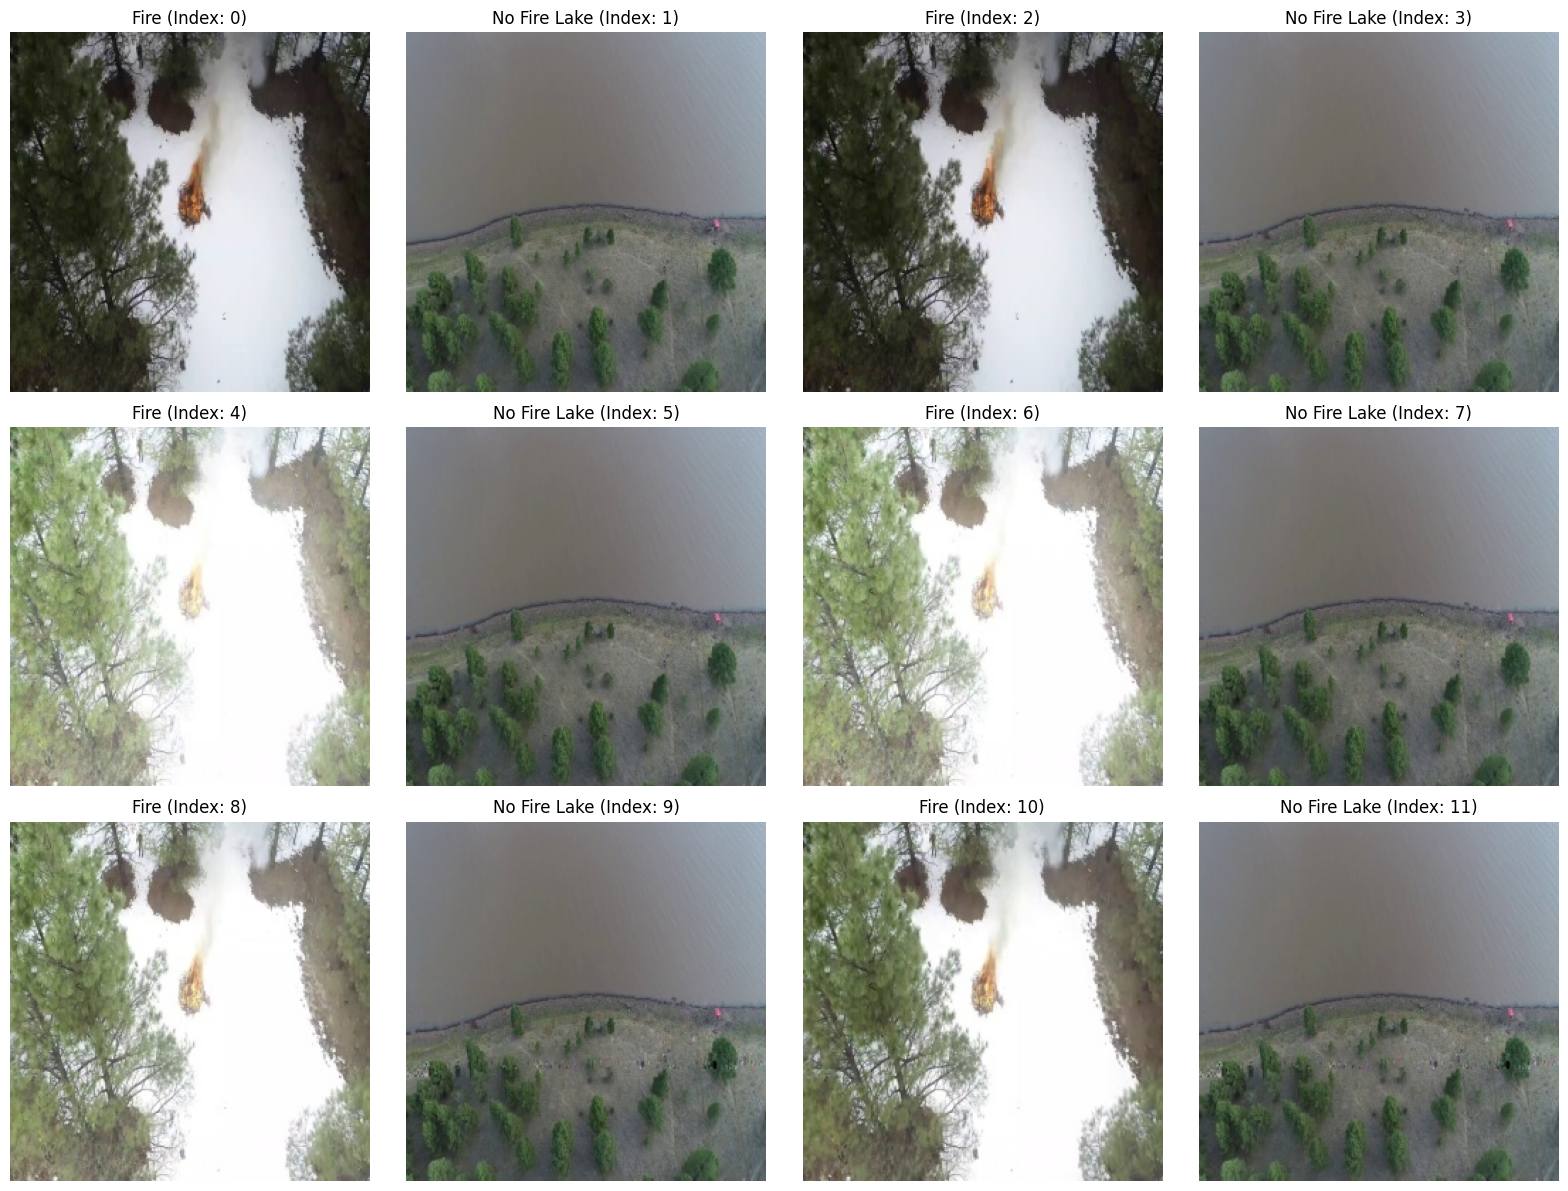

In [ ]:
def getImage(hasFire, whichImg):
    """Get one of the training images"""
    
    if hasFire:
        label = "Fire"
        filename = f'Training_Bi/Fire/resized_frame{whichImg}.jpg'
    else:
        label = "No Fire"
        filename = f'Training_Bi/No_Fire/resized_frame{whichImg}.jpg'
        
        if not os.path.isfile(filename):
            label = "No Fire Lake"
            filename = f'Training_Bi/No_Fire/lake_resized_lake_frame{whichImg}.jpg'
            
    return label, imageio.imread(filename)

ig, axes = plt.subplots(3, 4, figsize=(16, 12)) 
axes = axes.flatten()

# Display 12 images (6 with fire and 6 without fire)
for i in range(12):    
    is_fire = i % 2 == 0 
    label, im = getImage(is_fire, i)
    axes[i].imshow(im)
    axes[i].set_title(f"{label} (Index: {i})")
    axes[i].axis('off')  

plt.tight_layout()
plt.show()

The plots above further highlight the issue of frame repetition. Due to the dataset being extracted from video, consecutive frames are often nearly identical, showing very little variation between images. This results in repeated patterns across the dataset, where both the visual appearance and pixel distributions remain highly similar.

This affect is shown in my first model runs. An example is shown below that simply creates a train test validation split from the given test and training files and runs a simpler CNN model. This basic model uses the Adam optimizers and metrics for accuracy, recall and precision


In [ ]:
# loading the datasets from the directories and splitting into training, validation and test sets
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Training_Bi/",
    validation_split=0.15,
    subset="training",
    seed=Random_seed,
    image_size=(Image_size, Image_size),
    batch_size=None,
    class_names=["No_Fire", "Fire"]
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Training_Bi/",
    validation_split=0.15,
    subset="validation",
    seed=Random_seed,
    image_size=(Image_size, Image_size),
    batch_size=None,
    class_names=["No_Fire", "Fire"]
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Test/",
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=False,
    class_names=["No_Fire", "Fire"]
)

# auto-tuning the datasets for performance and batching them
train_ds = (
    train_ds_raw
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    val_ds_raw
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    test_ds_raw
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

# simple CNN model with two convolutional layers, sigmoid activation for binary classification
model = keras.models.Sequential([
    keras.layers.Conv2D(8, 3, activation='relu', padding='same', input_shape=(Image_size, Image_size, 3)),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', 
             keras.metrics.Recall(name='recall'), 
             keras.metrics.Precision(name='precision')]
)

# train the model for 10 epochs and evaluate on the test set
model.fit(train_ds, epochs=10, validation_data=val_ds, verbose=0)


# evaluating the model
loss, acc, recall, precision = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f} | Accuracy: {acc:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")


# evaluting the model at different thresholds and plotting the F1 score and a confustion matrix at the best threshold
preds = model.predict(test_ds)
true_labels = np.concatenate([y.numpy() for _, y in test_ds])

val_preds = model.predict(val_ds)
val_true = np.concatenate([y.numpy() for _, y in val_ds])

# tuning the threshold for best F1 score on the validation set
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(val_true, (val_preds > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.2f}  (Val F1={max(f1_scores):.4f})")


# plot the F1 scores at different thresholds and the confusion matrix at the best threshold
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Best = {best_threshold:.2f}')
plt.xlabel('Threshold'); plt.ylabel('F1'); plt.title('Threshold Tuning'); plt.legend()
plt.show()

pred_classes = (preds > best_threshold).astype(int).flatten()
print(confusion_matrix(true_labels, pred_classes))
print(classification_report(true_labels, pred_classes, target_names=['No_Fire', 'Fire']))

The above model clearly doens't fit well to the data. There is an aparent bias due to the size of both classes leading the model to predict all images as fire. Significant data processing is needed to produce a reasonable classifier.

### Data processing

To deal with these issues, multiple processing techniques are used:

* Normalisation : All images are scaled between 0 and 1. This stabilises training and ensures consistent input values across the dataset.

* Geometric Transformations : Random horizontal and vertical flips, along with 90° rotations, are applied. This allows the model to learn features independent of orientation and positioning.

* Colour Variation : Brightness, contrast, saturation and hue are randomly adjusted. This helps simulate different lighting conditions and prevents the model from relying too heavily on specific colour patterns.

* Environmental Effects : A random haze effect is introduced to mimic smoke or atmospheric interference. Additionally, slight blurring is applied in some cases to simulate motion blur or camera imperfections.

These transformations are applied randomly, meaning each image can appear slightly different each time it is seen by the model. This effectively increases the diversity of the dataset without requiring additional data collection.

The augmentation is only applied to the training data, whilst validation and test data are kept unchanged to ensure a fair evaluation of model performance. The effect of this is discussed later on.

In [ ]:
def apply_blur(img):
    ''' Apply a simple average blur to the input image to simulate 
        motion blur or out of focus blur.'''

    img = tf.expand_dims(img, 0)
    img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
    return tf.squeeze(img, 0)

def augment(image, label):
    ''' Apply random augmentations to the input image to increase the 
    diversity of the training data and improve model robustness.'''

    # normalize to [0,1] and apply random flips, rotations, brightness/contrast/saturation/hue adjustments
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform((), 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.05)
    
    # add random haze effect by blending the image with a light gray haze
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7

    # randomly apply the haze effect to some images to simulate different weather conditions
    image = tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: image * (1 - haze_intensity) + haze * haze_intensity,
        lambda: image
    )

    # randomly apply a blur effect to some images to simulate motion blur or out of focus blur
    image = tf.cond(
        tf.random.uniform(()) > 0.6,
        lambda: apply_blur(image),
        lambda: image
    )

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def normalize(image, label):
    ''' Normalize the input image to [0,1] range for better training stability.'''
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def load_and_preprocess(path, label):
    ''' Load the image from the given path and preprocess it by resizing to the target size.'''
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [Image_size, Image_size])
    return img, label

def prepare_dataset(paths, labels, use_aug=False, shuffle=True):
    ''' Prepare a tf.data.Dataset from the given image paths and labels, 
    with optional augmentation and shuffling.'''

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    # shuffle the dataset if specified to improve training randomness and generalization
    if shuffle:
        ds = ds.shuffle(len(paths))
    ds = ds.map(load_and_preprocess)
    if use_aug:
        ds = ds.map(augment)
    ds = ds.map(normalize).batch(Batch).prefetch(tf.data.AUTOTUNE)
    return ds

Class weights are a significant problem in this project as well. Due to the imbalance between Fire and No Fire images, the model can become biased towards the more common class. weights are applied during training so that errors on the minority class (Fire) are penalised more heavily than the majority class.

In [ ]:

def compute_class_weights(ds):
    ''' Compute class weights based on the distribution of labels in 
    the dataset to handle class imbalance.'''

    # extract labels from the dataset and compute class weights using inverse frequency
    labels = np.array([y.numpy() for _, y in ds])
    counts = np.bincount(labels)
    total = len(labels)
    weights = {i: total / (len(counts) * c) for i, c in enumerate(counts)}
    print(f"Class weights: {weights}")
    return weights

class_weights = compute_class_weights(train_ds_raw)

The Below code shows a simplification of my next attempts. These use the defined data augmentation and processing functions above. While helping reduce overfitting by adding noise and random variance to the data, the model still tends to over predict everything as fire. While for this Binary model the affect isnt so severe, for more unbalanced classes this would become more signficant and so will be investigated now in preperation for the Ternary model.

Found 39375 files belonging to 2 classes.
Using 33469 files for training.
Found 39375 files belonging to 2 classes.
Using 5906 files for validation.
Found 8617 files belonging to 2 classes.
Class weights: {0: 1.3716803278688525, 1: 0.7868023884526776}


C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6125 - loss: 0.8281 - precision: 0.6088 - recall: 0.9796
Test Loss: 0.8281 | Accuracy: 0.6125 | Recall: 0.9796 | Precision: 0.6088
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Best threshold: 0.10  (Val F1=0.7008)


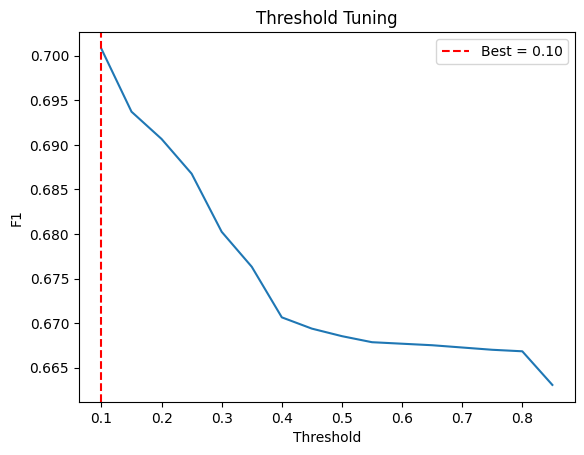

[[  54 3426]
 [   0 5137]]
              precision    recall  f1-score   support

     No_Fire       1.00      0.02      0.03      3480
        Fire       0.60      1.00      0.75      5137

    accuracy                           0.60      8617
   macro avg       0.80      0.51      0.39      8617
weighted avg       0.76      0.60      0.46      8617



In [ ]:

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Training_Bi/",
    validation_split=0.15,
    subset="training",
    seed=Random_seed,
    image_size=(Image_size, Image_size),
    batch_size=None,
    class_names=["No_Fire", "Fire"]
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Training_Bi/",
    validation_split=0.15,
    subset="validation",
    seed=Random_seed,
    image_size=(Image_size, Image_size),
    batch_size=None,
    class_names=["No_Fire", "Fire"]
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Test/",
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=False,
    class_names=["No_Fire", "Fire"]
)


train_ds = (
    train_ds_raw
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    val_ds_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    test_ds_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

model = keras.models.Sequential([
    keras.layers.Conv2D(8, 3, activation='relu', padding='same', input_shape=(Image_size, Image_size, 3)),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
)

model.fit(train_ds, epochs=10, validation_data=val_ds, verbose=0)

loss, acc, recall, precision = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f} | Accuracy: {acc:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")

preds = model.predict(test_ds)
true_labels = np.concatenate([y.numpy() for _, y in test_ds])

val_preds = model.predict(val_ds)
val_true = np.concatenate([y.numpy() for _, y in val_ds])

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(val_true, (val_preds > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.2f}  (Val F1={max(f1_scores):.4f})")

plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Best = {best_threshold:.2f}')
plt.xlabel('Threshold'); plt.ylabel('F1'); plt.title('Threshold Tuning'); plt.legend()
plt.show()

pred_classes = (preds > best_threshold).astype(int).flatten()
print(confusion_matrix(true_labels, pred_classes))
print(classification_report(true_labels, pred_classes, target_names=['No_Fire', 'Fire']))

As discussed, the F1 score is strong for Fire predictions but close to 0 for No Fire, indicating the model is overfitting to background features rather than learning meaningful fire-related patterns, effectively defaulting to one class.

### Data reduction : 

The level of similarity in each image is biasing the model, associating features such as background, lighting, or terrain with the label rather than the presence of fire itself.

To address this, multiple approaches will be explored and compared:

Frame Skipping : Selecting 1 in every 30 frames to reduce repetition and enforce greater variation between samples

Image Hashing : Removing near-duplicate images based on similarity detection
Baseline (No Removal) : Using the full dataset without filtering

These methods will be evaluated by comparing the performance of a smaller model trained on each version of the dataset. This will help determine whether reducing repetition improves generalisation and overall model accuracy.
Downsampling will also be explored by reducing the overall dataset size while maintaining class balance, helping to further limit repeated and redundant information. This aims to prevent the model from overfitting to highly similar frames and encourage it to learn more generalisable features rather than memorising patterns present in the dataset.


In [ ]:
def get_clean_data_ImageHash(dirs):
    ''' Load image paths and labels from the given directories, 
    compute perceptual hashes to identify and remove duplicates, 
    and return the cleaned lists of paths and labels.'''

    # iterate through the directories and class subdirectories to collect all image paths and labels
    all_paths, all_labels = [], []
    for d in dirs:

        # get class names and assign integer labels, then collect file paths for each class
        class_names = sorted(os.listdir(d))
        class_to_idx = {name: i for i, name in enumerate(class_names)}
        for class_name in class_names:

            # construct the class path and check if it's a directory, then list all files and extend the paths and labels lists
            c_path = os.path.join(d, class_name)
            if not os.path.isdir(c_path): continue
            files = [os.path.join(c_path, f) for f in os.listdir(c_path)]
            all_paths.extend(files)
            all_labels.extend([class_to_idx[class_name]] * len(files))
    
    # compute perceptual hashes for all images
    unique_hashes = {}
    clean_paths, clean_labels = [], []
    print(f"Total raw files: {len(all_paths)}")

    # keep only unique hashes to filter out duplicates
    for p, l in zip(all_paths, all_labels):
        try:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h not in unique_hashes:
                    unique_hashes[h] = p
                    clean_paths.append(p)
                    clean_labels.append(l)
        except: continue
    print(f"Total unique files: {len(clean_paths)}")
    return clean_paths, clean_labels


def get_clean_data_OneIn30(dirs, skip_rate=15, min_samples_per_class=30):
    ''' Load image paths and labels from the given directories, and return a 
    balanced subset of the data by sampling one in every skip_rate images'''

    # define a dictionary to hold file paths for each class
    class_files = {}
    class_to_idx = {}
    # iterate through the directories and class subdirectories to collect all image paths and labels
    for d in dirs:
        class_names = sorted(os.listdir(d))
        for i, name in enumerate(class_names):
            class_to_idx[name] = i
        for class_name in class_names:
            c_path = os.path.join(d, class_name)
            if not os.path.isdir(c_path): continue
            files = sorted([os.path.join(c_path, f) for f in os.listdir(c_path)])
            class_files.setdefault(class_name, []).extend(files)

    # sample one in every skip_rate images for each class, ensuring at least min_samples_per_class samples per class
    all_paths, all_labels = [], []
    for class_name, files in class_files.items():
        effective_rate = min(skip_rate, max(1, len(files) // min_samples_per_class))
        sampled = files[::effective_rate]
        all_paths.extend(sampled)
        all_labels.extend([class_to_idx[class_name]] * len(sampled))
        print(f"  {class_name}: {len(files)} raw -> {len(sampled)} sampled (rate=1/{effective_rate})")

    # print the total number of sampled files and return the lists of paths and labels
    print(f"Total sampled files: {len(all_paths)}")
    return all_paths, all_labels

def balance_split(paths, labels):
    ''' Balance the dataset by undersampling the majority class to match the count of the minority class.'''

    # compute the count of samples for each class, shuffle the combined list of paths and labels
    counts = Counter(labels)
    min_count = min(counts.values())
    combined = list(zip(paths, labels))
    random.shuffle(combined)
    bal_p, bal_l = [], []
    class_seen = Counter()
    # iterate through the combined list of paths and labels, and keep only min_count samples for each class to create a balanced dataset
    for p, l in combined:
        if class_seen[l] < min_count:
            bal_p.append(p)
            bal_l.append(l)
            class_seen[l] += 1
    return bal_p, bal_l


### Running the Experiments

I know have a good sense of what proper data processing is needed. To verify all the previous methods I've developed before will be combined and or compared. Below is my code to combine various hashing, random picking, downsampling or weighting methods. It will then be compared in a graph and discussed.

In [ ]:
def run_experiment(results, method='hashing', balancing='weights', use_aug=False):
    ''' Run a training and evaluation experiment with the specified data cleaning method, balancing strategy, and augmentation setting.'''

    # print the experiment configuration
    print(f"Running: method={method}, balancing={balancing}, aug={use_aug}")

    # load and clean the data using the specified method and split the data into training, validation and test sets
    if method == 'hashing':
        paths, labels = get_clean_data_ImageHash(["Training_Bi/"])
        te_p, te_l = get_clean_data_ImageHash(["Test/"])
    else:
        paths, labels = get_clean_data_OneIn30(["Training_Bi/"], skip_rate=15)
        te_p, te_l = get_clean_data_OneIn30(["Test/"], skip_rate=15)

    tr_p, val_p, tr_l, val_l = train_test_split(
        paths, labels, test_size=0.2, random_state=Random_seed, stratify=labels
    )

    print(f"  Train: {Counter(tr_l)} | Val: {Counter(val_l)} | Test: {Counter(te_l)}")
    # provide a reference point for model performance using majority class
    neg_test, pos_test = np.bincount(te_l)
    print(f"  Majority-class baseline accuracy: {max(neg_test, pos_test) / len(te_l):.3f}")

    # applying specified balancing technique
    weights = None
    if balancing == 'downsample':
        tr_p, tr_l = balance_split(tr_p, tr_l)
        print(f"  After downsample - Train: {Counter(tr_l)}")
    else:
        cls_weights = compute_class_weight('balanced', classes=np.unique(tr_l), y=tr_l)
        weights = {i: min(w, 10.0) for i, w in enumerate(cls_weights)}

    # prepare the datasets with optional augmentation for training and no augmentation for validation and test
    train_ds = prepare_dataset(tr_p,  tr_l,  use_aug=use_aug)
    val_ds   = prepare_dataset(val_p, val_l, use_aug=False)
    test_ds  = prepare_dataset(te_p,  te_l,  use_aug=False, shuffle=False)

    # simple CNN for test purposes
    model = keras.models.Sequential([
        keras.layers.Input(shape=(Image_size, Image_size, 3)),
        keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    # compiling model with Adam optimizer, binary crossentropy loss and metrics for accuracy, recall and precision
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
    )

    model.fit(train_ds, epochs=10, validation_data=val_ds, class_weight=weights, verbose=0)

    # eveluate the model on the test set and return scores
    eval_res = model.evaluate(test_ds, verbose=0, return_dict=True)

    results.append({
        'Augmentation': use_aug,
        'Accuracy':  eval_res.get('accuracy', 0),
        'Recall':    eval_res.get('recall', 0),
        'Precision': eval_res.get('precision', 0)
    })
    keras.backend.clear_session()
    return results

In [ ]:
results = []

# run all combinations of data cleaning methods, balancing strategies and augmentation settings to evaluate their impact on model performance
run_experiment(results, method='hashing', balancing='weights',    use_aug=False)
run_experiment(results, method='hashing', balancing='weights',    use_aug=True)
run_experiment(results, method='hashing', balancing='downsample', use_aug=False)
run_experiment(results, method='hashing', balancing='downsample', use_aug=True)

run_experiment(results, method='picking', balancing='weights',    use_aug=False)
run_experiment(results, method='picking', balancing='weights',    use_aug=True)
run_experiment(results, method='picking', balancing='downsample', use_aug=False)
run_experiment(results, method='picking', balancing='downsample', use_aug=True)

Running: method=hashing, balancing=weights, aug=False
Total raw files: 39375
Total unique files: 9050
Total raw files: 8617
Total unique files: 3641
  Train: Counter({0: 4126, 1: 3114}) | Val: Counter({0: 1031, 1: 779}) | Test: Counter({0: 1952, 1: 1689})
  Majority-class baseline accuracy: 0.536
Running: method=hashing, balancing=weights, aug=True
Total raw files: 39375
Total unique files: 9050
Total raw files: 8617
Total unique files: 3641
  Train: Counter({0: 4126, 1: 3114}) | Val: Counter({0: 1031, 1: 779}) | Test: Counter({0: 1952, 1: 1689})
  Majority-class baseline accuracy: 0.536
Running: method=hashing, balancing=downsample, aug=False
Total raw files: 39375
Total unique files: 9050
Total raw files: 8617
Total unique files: 3641
  Train: Counter({0: 4126, 1: 3114}) | Val: Counter({0: 1031, 1: 779}) | Test: Counter({0: 1952, 1: 1689})
  Majority-class baseline accuracy: 0.536
  After downsample - Train: Counter({0: 3114, 1: 3114})
Running: method=hashing, balancing=downsample, a

[{'Augmentation': False,
  'Accuracy': 0.5328206419944763,
  'Recall': 0.48667851090431213,
  'Precision': 0.49637681245803833},
 {'Augmentation': True,
  'Accuracy': 0.5363910794258118,
  'Recall': 0.0005920663243159652,
  'Precision': 1.0},
 {'Augmentation': False,
  'Accuracy': 0.538313627243042,
  'Recall': 0.46654826402664185,
  'Precision': 0.5025510191917419},
 {'Augmentation': True,
  'Accuracy': 0.5363910794258118,
  'Recall': 0.0005920663243159652,
  'Precision': 1.0},
 {'Augmentation': False,
  'Accuracy': 0.6191304326057434,
  'Recall': 0.5043103694915771,
  'Precision': 0.529411792755127},
 {'Augmentation': True,
  'Accuracy': 0.5965217351913452,
  'Recall': 0.0,
  'Precision': 0.0},
 {'Augmentation': False,
  'Accuracy': 0.5669565200805664,
  'Recall': 0.8448275923728943,
  'Precision': 0.47921761870384216},
 {'Augmentation': True,
  'Accuracy': 0.5965217351913452,
  'Recall': 0.0,
  'Precision': 0.0}]

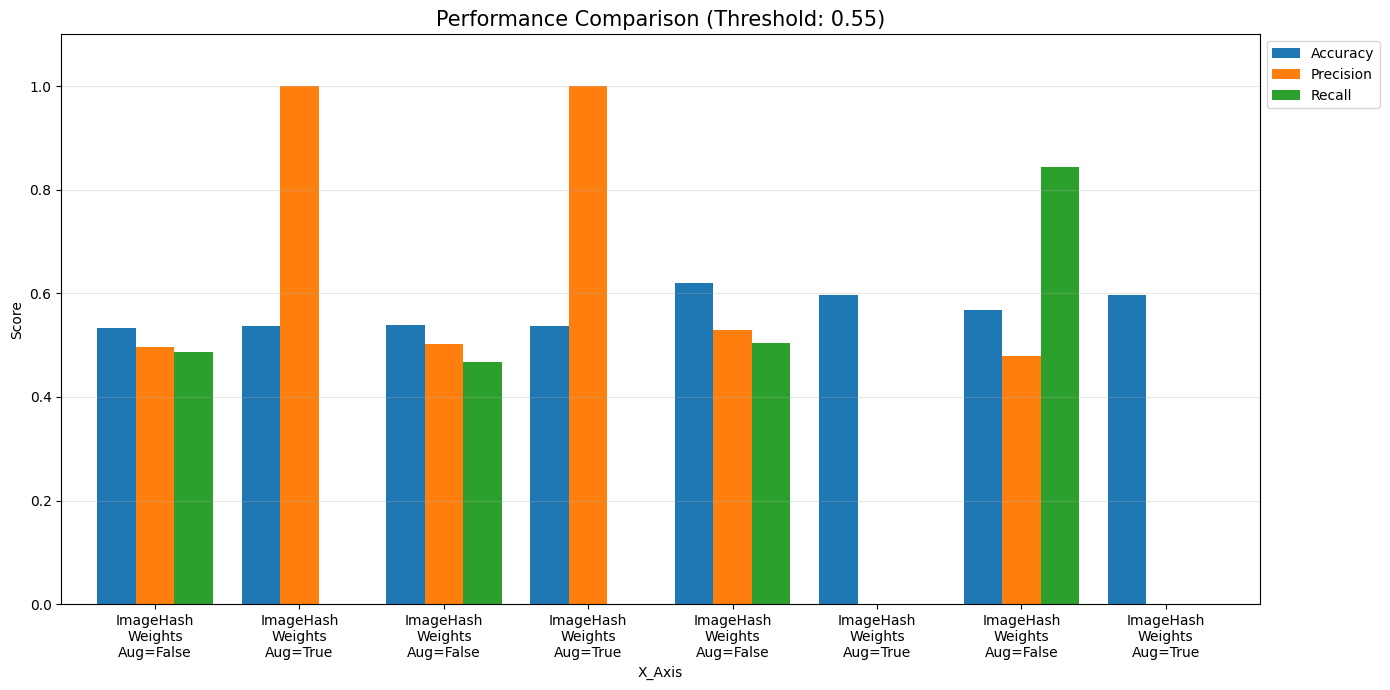

In [ ]:
# create a DataFrame from the results and plot the performance metrics for each experiment configuration
df = pd.DataFrame(results)

df['Method'] = 'ImageHash'
df['Balancing'] = 'Weights'

# combined x axis for ease of comparison
df['X_Axis'] = (
    df['Method'] + "\n" +
    df['Balancing'] + "\n" +
    "Aug=" + df['Augmentation'].astype(str)
)

ax = df.plot(
    kind='bar', 
    x='X_Axis', 
    y=['Accuracy', 'Precision', 'Recall'], 
    figsize=(14, 7),
    width=0.8
)

plt.title('Performance Comparison (Threshold: 0.55)', fontsize=15)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The complexity of the data causes model precision and recall to fluctuate significantly, however a general trend is still observable.

Image hashing performs well as it retains more images, meaning more data is available for training, which generally improves performance. In contrast, selecting 1 in every 30 frames is very fast and efficient, but the reduced dataset size leads to underperformance due to lack of data.

Augmentation is generally beneficial, helping improve generalisation. Downsampling is more effective than class weighting as it directly reduces class imbalance rather than just adjusting its impact during training. However, due to the not so intense imbalance in the dataset, neither downsampling nor class weighting has a significant effect on overall performance.

Overall, methods such as image hashing and frame skipping provide an increase to accuracy but do not impact performance as strongly as observed in the ternary model.


# Hue Comparison

My final comparison for the Binary data is the effect of hue. As fire is specifically red, and investigation as to whether hue obscures the model from detecting red fires is warranted. A simple flexible augmentation processing sequence and model is run below and dicussed as to whether hue is better on or off.

Total raw files: 39375
Total unique files: 9050
Total raw files: 8617
Total unique files: 3641
Training - Random Hue: True
Training - Random Hue: False

--- Hue Comparison Results ---
   Hue Augmentation  Accuracy    Recall  Precision
0              True  0.432299  0.857904   0.442308
1             False  0.542159  0.543517   0.506064


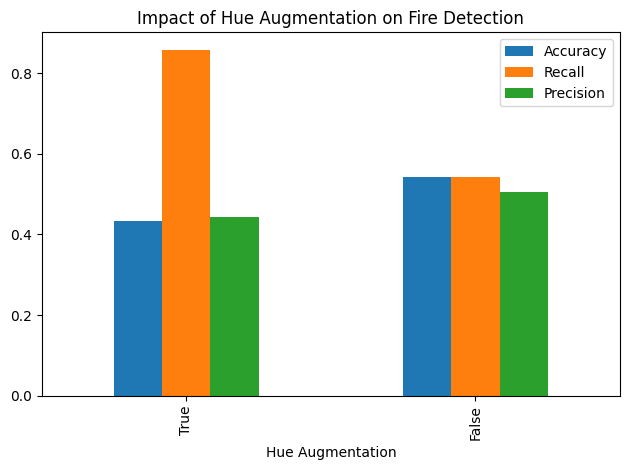

In [ ]:
def augment_flexible(image, label, use_hue=True):
    ''' Apply a flexible set of augmentations to the input image, with optional hue adjustment.'''
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform((), 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    
    # optionally apply random hue adjustment to simulate different lighting conditions and color variations in fire detection scenarios
    if use_hue:
        image = tf.image.random_hue(image, max_delta=0.05)
    
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7
    image = tf.cond(tf.random.uniform(()) > 0.5, 
                    lambda: image * (1 - haze_intensity) + haze * haze_intensity, 
                    lambda: image)
    
    # randomly apply a blur effect to some images to simulate motion blur or out of focus blur
    image = tf.cond(tf.random.uniform(()) > 0.6, lambda: apply_blur(image), lambda: image)
    return tf.clip_by_value(image, 0.0, 1.0), label

def run_hue_comparison():
    ''' Run an experiment to compare the impact of using hue augmentation on model performance for fire detection.'''

    # load and clean the data using perceptual hashing to remove duplicates, and split into training, validation and test sets
    paths, labels = get_clean_data_ImageHash(["Training_Bi/"])
    te_p, te_l = get_clean_data_ImageHash(["Test/"])
    tr_p, val_p, tr_l, val_l = train_test_split(
        paths, labels, test_size=0.2, random_state=Random_seed, stratify=labels
    )
    
    cls_weights = compute_class_weight('balanced', classes=np.unique(tr_l), y=tr_l)
    weights = dict(enumerate(cls_weights))

    results = []
    # compare training with and without hue augmentation to evaluate its impact on accuracy, recall and precision for fire detection
    for use_hue in [True, False]:
        print(f"Training - Random Hue: {use_hue}")
        
        train_ds = (tf.data.Dataset.from_tensor_slices((tr_p, tr_l))
                    .shuffle(len(tr_p))
                    .map(load_and_preprocess)
                    .map(lambda x, y: augment_flexible(x, y, use_hue=use_hue))
                    .batch(Batch).prefetch(tf.data.AUTOTUNE))
        
        val_ds  = prepare_dataset(val_p, val_l, use_aug=False)
        test_ds = prepare_dataset(te_p,  te_l,  use_aug=False, shuffle=False)

        # simple CNN model for test purposes
        model = keras.models.Sequential([
            keras.layers.Input(shape=(Image_size, Image_size, 3)),
            keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
            keras.layers.MaxPooling2D(),
            keras.layers.Dropout(0.2),
            keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
            keras.layers.MaxPooling2D(),
            keras.layers.Dropout(0.3),
            keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
            keras.layers.MaxPooling2D(),
            keras.layers.Dropout(0.3),
            keras.layers.GlobalAveragePooling2D(),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dropout(0.4),
            keras.layers.Dense(1, activation='sigmoid')
        ])

        # compile the model with Adam optimizer, binary crossentropy loss and metrics for accuracy, recall and precision
        model.compile(
            optimizer=keras.optimizers.Adam(1e-4),
            loss='binary_crossentropy',
            metrics=['accuracy', keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
        )

    
        model.fit(train_ds, epochs=30, validation_data=val_ds, class_weight=weights, verbose=0)
        
        # evaluate the model on the test set and store the results for comparison
        eval_res = model.evaluate(test_ds, verbose=0)
        results.append({
            'Hue Augmentation': use_hue,
            'Accuracy':  eval_res[1],
            'Recall':    eval_res[2],
            'Precision': eval_res[3]
        })
        keras.backend.clear_session()

    # create a DataFrame from the results and plot the performance metrics to compare the impact of hue augmentation on fire detection performance
    res_df = pd.DataFrame(results)
    print("\n--- Hue Comparison Results ---")
    print(res_df)
    res_df.plot(kind='bar', x='Hue Augmentation', y=['Accuracy', 'Recall', 'Precision'],
                title='Impact of Hue Augmentation on Fire Detection')
    plt.tight_layout()
    plt.show()

run_hue_comparison()

As is shown above, generally having hue on is better, As the model learns features pertaining to the fires shape and effect rather than colour, a useful model generalisation given all the things in a forest that could potentially be red.

### Conclusion

To conclude, the code implements a comprehensive pipeline for training and evaluating a CNN model for fire detection in images, including data loading, cleaning, augmentation, model training and evaluation, and comparison of different data cleaning methods, balancing strategies and augmentation settings to understand their impact on model performance. The use of perceptual hashing helps to remove duplicate images, while the flexible augmentation function allows for simulating various real-world conditions. The experiments show how different configurations affect accuracy, recall and precision.

Specifically It shows that in a simpler classifier like a Binary Fire vs No Fire classifier, the most generalised data is most useful as the model would be liable to overpredict one class and forget about the other. Image hashing, downsampling and augmentation is an effective technique to produce good data for a model to use.